In [1]:
# Import required libraries
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import importlib


In [3]:

# Add current directory to path to import our modules
if '.' not in sys.path:
    sys.path.append('.')

# Import our modules
from models import ObjectDetectionModel, ObjectDetectionDataModule
from utils import plot_image
# from onnx_conversion import export_to_onnx, verify_onnx_model


In [7]:

# reload modules to get the latest changes
import models
import utils
# import onnx_conversion
import dataset

importlib.reload(models)
importlib.reload(utils)
# importlib.reload(onnx_conversion)
importlib.reload(dataset)

from models import ObjectDetectionModel, ObjectDetectionDataModule, LightweightGridDetectionModel, SafetyLosses, LightweightGridDetectionModelUYVY, ObjectDetectionDataModuleUYVY 
from utils import plot_image, plot_side_by_side, compare_pytorch_onnx_side_by_side
# from onnx_conversion import export_to_onnx, verify_onnx_model
from dataset import CustomImageDataset, CustomImageDatasetUYVY


# Step 0: Initialize the model and data module

In [ ]:
import os
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define constants
width = 520
height = 240
image_dir_train = "./Dataset/dataset_syn/images/train"
image_dir_val = "./Dataset/dataset_syn/images/val"

# Set up grid lines
grid_lines = [[0, 0.2, 0.4, 0.6, 0.8, 1], [0, 1]]
grid_lines[0] = [line * width for line in grid_lines[0]]
grid_lines[1] = [line * height for line in grid_lines[1]]
danger_levels = 3

# Training parameters
max_epochs = 100  # Adjust as needed
batch_size = 8
checkpoint_path = "./model_checkpoints"
os.makedirs(checkpoint_path, exist_ok=True)

# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath=checkpoint_path,
    filename='object_detection-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    monitor='val_loss',
    mode='min'
)

# Training flag - set to True if you want to train the model, False to load a saved model
train_model = True

# Initialize our ONNX-compatible model
# model = ObjectDetectionModel(grid_lines, danger_levels, input_shape=(3, height, width))
model = LightweightGridDetectionModel(grid_lines, danger_levels, input_shape=(3, height, width))

# Initialize the data module
data_module = ObjectDetectionDataModule(
    image_dir_train, 
    image_dir_val, 
    width, 
    height, 
    grid_lines, 
    danger_levels, 
    batch_size=batch_size, 
    device=device
)

Using device: cuda


# Step 1: Investigate Dataset
# Class balance

In [175]:
def analyze_dataset(data_module):
    data_module.setup()

    
    print("Dataset Statistics:")
    print(f"Training samples: {len(data_module.train_dataset)}")
    print(f"Validation samples: {len(data_module.val_dataset)}")
    
    # Analyze label distribution
    all_labels = []
    for _, labels in data_module.train_dataloader():
        all_labels.append(labels.cpu().numpy())
    all_labels = np.concatenate(all_labels)
    
    print("\nLabel Statistics:")
    print(f"Label shape: {all_labels.shape}")
    
    # Calculate class distribution
    safe_ratio = np.mean(all_labels[:, 0] > 0.5)
    warning_ratio = np.mean(all_labels[:, 1] > 0.5)
    danger_ratio = np.mean(all_labels[:, 2] > 0.5)
    
    print("\nClass Distribution (using 0.5 threshold):")
    print(f"Safe cells: {safe_ratio:.2%}")
    print(f"Warning cells: {warning_ratio:.2%}")
    print(f"Danger cells: {danger_ratio:.2%}")
    
    # Check for potential issues
    print("\nPotential Issues:")
    print(f"NaN values: {np.isnan(all_labels).any()}")
    print(f"Inf values: {np.isinf(all_labels).any()}")

analyze_dataset(data_module)

[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
Dataset Statistics:
Training samples: 1409
Validation samples: 261

Label Statistics:
Label shape: (1409, 3, 5, 1)

Class Distribution (using 0.5 threshold):
Safe cells: 11.74%
Warning cells: 7.98%
Danger cells: 10.16%

Potential Issues:
NaN values: False
Inf values: False


# Label exclusivity

In [176]:
def analyze_label_exclusivity(data_module):
    data_module.setup()
    
    non_exclusive = 0
    missing_label = 0
    total_cells = 0
    
    # Analyze overlapping labels and count instances
    class_combinations = {
        'safe_only': 0,
        'warning_only': 0,
        'danger_only': 0,
        'overlapping': 0,
        'no_label': 0
    }
    
    confusion_matrix = np.zeros((3, 3))  # To see if there are common overlap patterns
    
    for _, labels in data_module.train_dataloader():
        labels = labels.cpu().numpy()
        
        # For each grid cell
        batch_size, classes, grid_x, grid_y = labels.shape
        total_cells += batch_size * grid_x * grid_y
        
        for b in range(batch_size):
            for x in range(grid_x):
                for y in range(grid_y):
                    cell_labels = labels[b, :, x, y]  # [safe, warning, danger]
                    active_labels = np.where(cell_labels > 0.5)[0]
                    
                    if len(active_labels) > 1:
                        non_exclusive += 1
                        class_combinations['overlapping'] += 1
                        # Record which classes are overlapping
                        for i in active_labels:
                            for j in active_labels:
                                if i < j:
                                    confusion_matrix[i, j] += 1
                    elif len(active_labels) == 0:
                        missing_label += 1
                        class_combinations['no_label'] += 1
                    else:
                        if active_labels[0] == 0:
                            class_combinations['safe_only'] += 1
                        elif active_labels[0] == 1:
                            class_combinations['warning_only'] += 1
                        elif active_labels[0] == 2:
                            class_combinations['danger_only'] += 1
    
    print(f"Total grid cells analyzed: {total_cells}")
    print(f"Cells with overlapping labels: {non_exclusive} ({(non_exclusive/total_cells)*100:.2f}%)")
    print(f"Cells with no labels: {missing_label} ({(missing_label/total_cells)*100:.2f}%)")
    print("\nClass combinations:")
    for combo, count in class_combinations.items():
        print(f"{combo}: {count} ({(count/total_cells)*100:.2f}%)")
    
    print("\nOverlap patterns (if any):")
    class_names = ['Safe', 'Warning', 'Danger']
    for i in range(3):
        for j in range(i+1, 3):
            if confusion_matrix[i, j] > 0:
                print(f"{class_names[i]} + {class_names[j]}: {int(confusion_matrix[i, j])} instances")

    return class_combinations, confusion_matrix

results = analyze_label_exclusivity(data_module)

[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
Total grid cells analyzed: 7045
Cells with overlapping labels: 0 (0.00%)
Cells with no labels: 4940 (70.12%)

Class combinations:
safe_only: 827 (11.74%)
warning_only: 562 (7.98%)
danger_only: 716 (10.16%)
overlapping: 0 (0.00%)
no_label: 4940 (70.12%)

Overlap patterns (if any):


In [177]:
def visualize_overlapping_labels(data_module, num_examples=3):
    data_module.setup()
    
    for _, (images, labels) in enumerate(data_module.train_dataloader()):
        batch_size = images.shape[0]
        for i in range(batch_size):
            # Check for overlapping labels
            label = labels[i]  # [3, grid_x, grid_y]
            has_overlap = False
            for x in range(label.shape[1]):
                for y in range(label.shape[2]):
                    cell_labels = label[:, x, y]
                    if sum(cell_labels > 0.5) > 1:
                        has_overlap = True
                        break
                if has_overlap:
                    break
            
            if has_overlap:
                # Create figure with 5 subplots:
                # Original image, Safe channel, Warning channel, Danger channel, Combined
                fig, axes = plt.subplots(1, 5, figsize=(25, 5))
                
                # Original image
                img = images[i].cpu().permute(1, 2, 0).numpy()
                axes[0].imshow(img)
                axes[0].set_title("Original Image")
                
                # Add grid lines to all plots
                for ax in axes:
                    for x in data_module.grid_lines[0]:
                        ax.axvline(x, color='blue', linestyle='--', alpha=0.3)
                    for y in data_module.grid_lines[1]:
                        ax.axhline(y, color='blue', linestyle='--', alpha=0.3)
                
                # Individual channels
                channel_names = ['Safe', 'Warning', 'Danger']
                colors = ['green', 'orange', 'red']
                
                for ch in range(3):
                    axes[ch+1].imshow(img)
                    axes[ch+1].set_title(f"{channel_names[ch]} Channel")
                    
                    # Show cells for this channel
                    for x in range(len(data_module.grid_lines[0]) - 1):
                        for y in range(len(data_module.grid_lines[1]) - 1):
                            if label[ch, x, y] > 0.5:
                                x1, x2 = data_module.grid_lines[0][x], data_module.grid_lines[0][x + 1]
                                y1, y2 = data_module.grid_lines[1][y], data_module.grid_lines[1][y + 1]
                                axes[ch+1].fill_between([x1, x2], [y1, y1], [y2, y2], 
                                                      color=colors[ch], alpha=0.4)
                
                # Combined visualization
                axes[4].imshow(img)
                axes[4].set_title("Combined (Overlapping)")
                
                # Show all active cells with different hatching patterns
                for x in range(len(data_module.grid_lines[0]) - 1):
                    for y in range(len(data_module.grid_lines[1]) - 1):
                        x1, x2 = data_module.grid_lines[0][x], data_module.grid_lines[0][x + 1]
                        y1, y2 = data_module.grid_lines[1][y], data_module.grid_lines[1][y + 1]
                        
                        # Create different hatch patterns for overlapping regions
                        active_channels = [ch for ch in range(3) if label[ch, x, y] > 0.5]
                        if len(active_channels) > 1:
                            for idx, ch in enumerate(active_channels):
                                axes[4].fill_between([x1, x2], [y1, y1], [y2, y2],
                                                   color=colors[ch], alpha=0.3,
                                                   hatch=['/', '\\', 'x'][idx])
                
                # Add legend to combined plot
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=color, alpha=0.4, label=name)
                                 for color, name in zip(colors, channel_names)]
                axes[4].legend(handles=legend_elements, loc='upper right')
                
                plt.tight_layout()
                plt.show()
                
                # Print the label values for overlapping cells
                print("\nOverlapping cell values:")
                for x in range(label.shape[1]):
                    for y in range(label.shape[2]):
                        cell_labels = label[:, x, y]
                        if sum(cell_labels > 0.5) > 1:
                            print(f"Grid cell [{x},{y}]: Safe={cell_labels[0]:.1f}, "
                                  f"Warning={cell_labels[1]:.1f}, Danger={cell_labels[2]:.1f}")
                
                num_examples -= 1
                if num_examples <= 0:
                    return

# Run the visualization
visualize_overlapping_labels(data_module)

[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels


# Step 2: Train the model or load from checkpoint

# Investigate Hierarchal Loss Functions


In [ ]:
import contextlib
import io
import os
import logging
import warnings
from collections import defaultdict
from sklearn.model_selection import KFold


# reload modules to get the latest changes
import models
import utils
import onnx_conversion
import dataset

importlib.reload(models)
importlib.reload(utils)
importlib.reload(onnx_conversion)
importlib.reload(dataset)

from models import ObjectDetectionModel, ObjectDetectionDataModule, LightweightGridDetectionModel, SafetyLosses
from utils import plot_image, plot_side_by_side, compare_pytorch_onnx_side_by_side
from onnx_conversion import export_to_onnx, verify_onnx_model
from dataset import CustomImageDataset


# Custom callback to log metrics
class MetricsCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.metrics_history = defaultdict(list)
        
    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        for key, value in metrics.items():
            if isinstance(value, torch.Tensor):
                self.metrics_history[key].append(value.item())
            else:
                self.metrics_history[key].append(value)

def suppress_lightning_logs(debug=False):
    """Context manager to suppress Lightning logs and warnings unless debug=True"""
    class NoOp:
        def __enter__(self): pass
        def __exit__(self, *args): pass

    if debug:
        # Don't suppress logs if in debug mode
        return NoOp()
    
    # Disable all logging in normal mode
    logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
    os.environ["PL_GLOBAL_SEED"] = "42"
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    
    return contextlib.ExitStack()

def run_cross_validation(image_dir, width, height, grid_lines, danger_levels, 
                        config_name, n_splits=5, n_epochs=20, debug=False):
    full_dataset = CustomImageDataset(
        image_dir, 
        width, 
        height, 
        grid_lines, 
        danger_levels, 
        "cpu"
    )
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    training_histories = []
    
    # Redirect stdout and suppress Lightning outputs
    temp_stdout = io.StringIO()
    
    with suppress_lightning_logs():
        for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(full_dataset)))):
            print(f"\rFold {fold + 1}/{n_splits}", end="", flush=True)
            
            fold_data_module = ObjectDetectionDataModule(
                image_dir_train=image_dir,
                image_dir_val=image_dir,
                width=width,
                height=height,
                grid_lines=grid_lines,
                danger_levels=danger_levels,
                batch_size=8,
                device="cuda" if torch.cuda.is_available() else "cpu",
                fold_indices=(train_idx, val_idx)
            )
            
            metrics_callback = MetricsCallback()
            model = LightweightGridDetectionModel(
                grid_lines,
                danger_levels,
                input_shape=(3, height, width),
                hierarchical_config=config_name
            )
            
            trainer_kwargs = {
                'max_epochs': n_epochs,
                'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
                'enable_progress_bar': debug,  # Show progress bar in debug mode
                'enable_model_summary': debug,  # Show model summary in debug mode
                'logger': False,
                'enable_checkpointing': False,
                'log_every_n_steps': 1 if debug else None,  # Log every step in debug mode
                'callbacks': [metrics_callback],
                'detect_anomaly': debug,  # Enable anomaly detection in debug mode
                'deterministic': False,
                'benchmark': True,
                'num_sanity_val_steps': 2 if debug else 0,
            }
            
            trainer = pl.Trainer(**trainer_kwargs)
            
            if debug:
                # Don't suppress output in debug mode
                trainer.fit(model, fold_data_module)
                results = trainer.validate(model, datamodule=fold_data_module)
            else:
                # Suppress output in normal mode
                with contextlib.redirect_stdout(temp_stdout), \
                    contextlib.redirect_stderr(temp_stdout), \
                    warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    trainer.fit(model, fold_data_module)
                    results = trainer.validate(model, datamodule=fold_data_module)
            
            fold_results.append(results[0])
            training_histories.append(metrics_callback.metrics_history)
        
    print()  # New line after progress
    return fold_results, training_histories

# Run evaluation for all configurations with cleaner output
def run_all_configurations(debug=False):
    # Suppress Lightning startup messages
    with suppress_lightning_logs(debug=debug):
        all_results = {}
        for config in SafetyLosses.CONFIGS.keys():
            print(f"\nEvaluating {config} configuration...")
            fold_results, histories = run_cross_validation(
                image_dir=image_dir_train,
                width=width,
                height=height,
                grid_lines=grid_lines,
                danger_levels=danger_levels,
                config_name=config,
                n_splits=5,
                n_epochs=50,
                debug=debug
            )
            result = {
                'fold_results': fold_results,
                'training_histories': histories
            }
            import pickle
            # Save results to pickle file
            filename = f"results/results_{config}.pkl"
            with open(filename, 'wb') as f:
                pickle.dump(result, f)
            all_results[config] = result

        return all_results

# Run the evaluation
all_results = run_all_configurations(debug=False)


Evaluating conservative configuration...
Fold 5/5

Evaluating balanced configuration...
Fold 5/5

Evaluating smooth configuration...
Fold 5/5

Evaluating balanced_plus configuration...
Fold 5/5

# Save results

In [218]:
print(type(all_results))

# Save to file

import json

with open("cross_validation_results.json", "w") as f:
    json.dump(all_results, f)


<class 'dict'>


In [315]:
# open all files from results and append to a single dictionary 
import pickle
import os

all_results = {}
for file in os.listdir("results"):
    if file.endswith(".pkl"):
        with open(f"results/{file}", 'rb') as f:
            result = pickle.load(f)
            all_results[file.replace("_result.pkl", "")] = result

# Visualize
left to right, top to bottom:
First plot shows total validation loss
Second plot shows validation accuracy on the safe class
Third plot shows the validation accuracy on the warning class
Fourth plot shows the validation accuracy on the danger class
Final plot shows how often we misclassify safe or warning as dangerous - less important than misclassifying dangerous as warning or safe. 

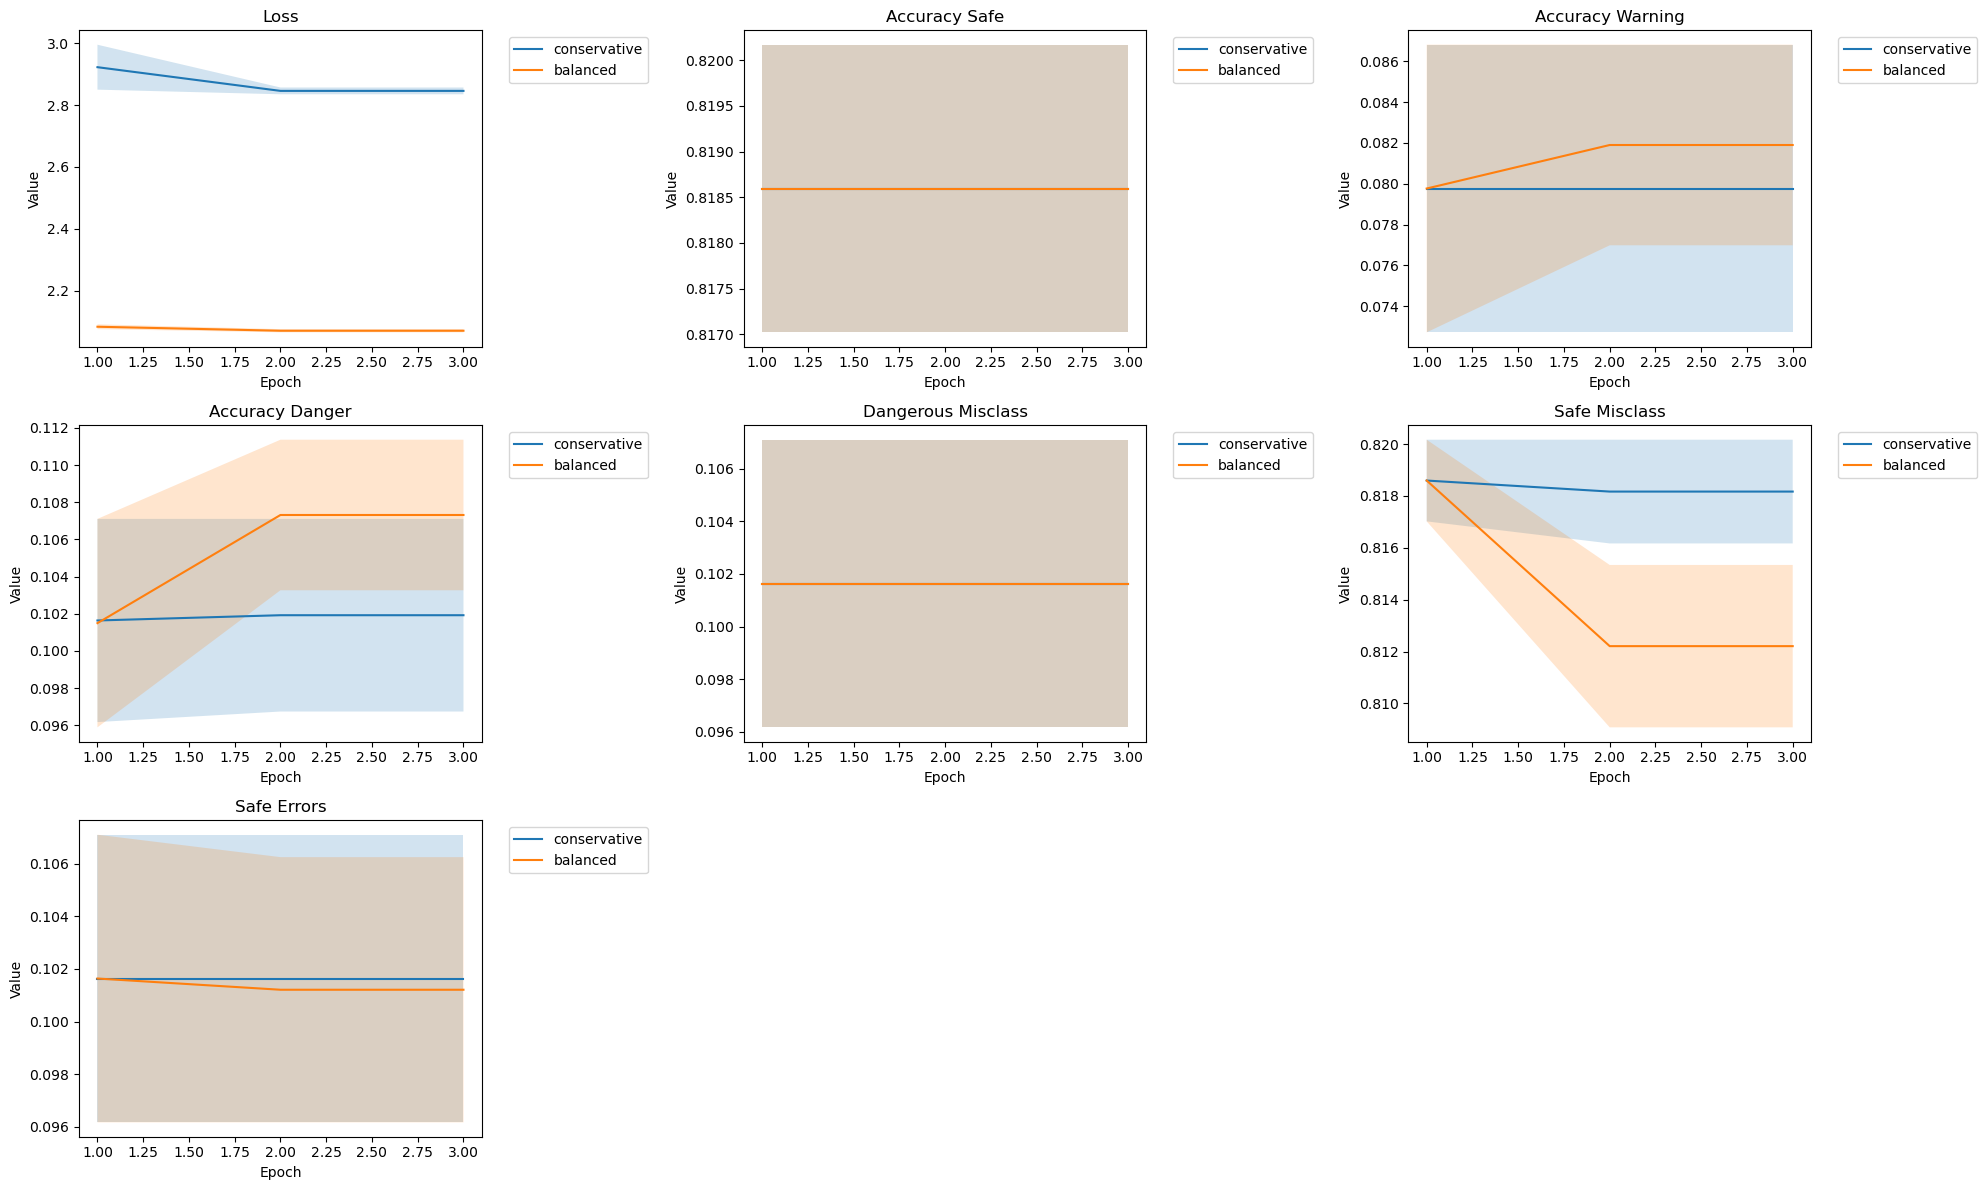


Summary Statistics:
--------------------------------------------------------------------------------
Configuration   Metric                    Mean ± Std          
--------------------------------------------------------------------------------
conservative    Loss                        2.8457 ± 0.0110  
conservative    Accuracy Safe               0.8186 ± 0.0016  
conservative    Accuracy Warning            0.0798 ± 0.0070  
conservative    Accuracy Danger             0.1019 ± 0.0052  
conservative    Dangerous Misclass          0.1016 ± 0.0055  
conservative    Safe Misclass               0.8182 ± 0.0020  
conservative    Safe Errors                 0.1016 ± 0.0055  
--------------------------------------------------------------------------------
balanced        Loss                        2.0710 ± 0.0052  
balanced        Accuracy Safe               0.8186 ± 0.0016  
balanced        Accuracy Warning            0.0819 ± 0.0049  
balanced        Accuracy Danger             0.1073 ± 

In [319]:
def plot_training_histories(all_results):
    metrics_to_plot = [
        'val_loss', 
        'val_accuracy_safe', 
        'val_accuracy_warning', 
        'val_accuracy_danger',
        'val_dangerous_misclass',
        'val_safe_misclass',
        'val_safe_errors'
    ]
    
    plt.figure(figsize=(20, 12))
    for i, metric in enumerate(metrics_to_plot, 1):
        plt.subplot(3, 3, i)
        for config, results in all_results.items():
            histories = results['training_histories']
            if not all(metric in h for h in histories):
                continue
                
            mean_history = np.mean([h[metric] for h in histories], axis=0)
            std_history = np.std([h[metric] for h in histories], axis=0)
            epochs = range(1, len(mean_history) + 1)
            
            plt.plot(epochs, mean_history, label=config)
            plt.fill_between(epochs, 
                           mean_history - std_history,
                           mean_history + std_history,
                           alpha=0.2)
        
        plt.title(metric.replace('val_', '').replace('_', ' ').title())
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

def print_summary_statistics(all_results):
    metric_order = [
        'val_loss',
        'val_accuracy_safe',
        'val_accuracy_warning',
        'val_accuracy_danger',
        'val_dangerous_misclass',
        'val_safe_misclass',
        'val_safe_errors'
    ]
    
    print("\nSummary Statistics:")
    print("-" * 80)
    print(f"{'Configuration':<15} {'Metric':<25} {'Mean ± Std':<20}")
    print("-" * 80)
    
    for config, results in all_results.items():
        metrics = defaultdict(list)
        
        for fold_result in results['fold_results']:
            for metric, value in fold_result.items():
                metrics[metric].append(value)
        
        for metric in metric_order:
            if metric in metrics:
                values = metrics[metric]
                mean = np.mean(values)
                std = np.std(values)
                metric_name = metric.replace('val_', '').replace('_', ' ').title()
                print(f"{config:<15} {metric_name:<25} {mean:>8.4f} ± {std:<8.4f}")
        print("-" * 80)
plot_training_histories(all_results)

print_summary_statistics(all_results)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | conv_features | Sequential | 3.8 K  | train
1 | classifier    | Sequential | 163    | train
2 | loss_fn       | BCELoss    | 0      | train
-----------------------------------------------------
3.9 K     Trainable params
0         Non-trainable params
3.9 K     Total params
0.016     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
Starting model training...
Training on 1409 images
Validating on 261 images
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels

Epoch 1/100
Train Loss: 0.3326, Val Loss: 0.4355

Epoch 2/100
Train Loss: 0.7857, Val Loss: 0.4013

Epoch 3/100
Train Loss: 0.1677, Val Loss: 0.3952

Epoch 4/100
Train Loss: 0.9167, Val Loss: 0.3999

Epoch 5/100
Train Loss: 0.3208, Val Loss: 0.3875

Epoch 6/100
Train Loss: 0.3744, Val Loss: 0.3858

Epoch 7/100
Train Loss: 0.2002, Val Loss: 0.3867

Epoch 8/100
Train Loss: 0.1742, Val Loss: 0.3831

Epoch 9/100
Train Loss: 0.9432, Val Loss: 0.3727

Epoch 10/100
Train Loss: 0.3785, Val Loss: 0.3800

Epoch 11/100
Train Loss: 0.3423, Val Loss: 0.3677

Epoch 12/100
Train Loss: 1.2232, Val Loss: 0.3701

Epoch 13/100
Train Loss: 0.7989, Val Loss: 0.3637

Epoch 14/100
Train Loss: 0.2355, Val Loss: 0.3769

Ep

`Trainer.fit` stopped: `max_epochs=100` reached.


Train Loss: 0.0426, Val Loss: 0.2968


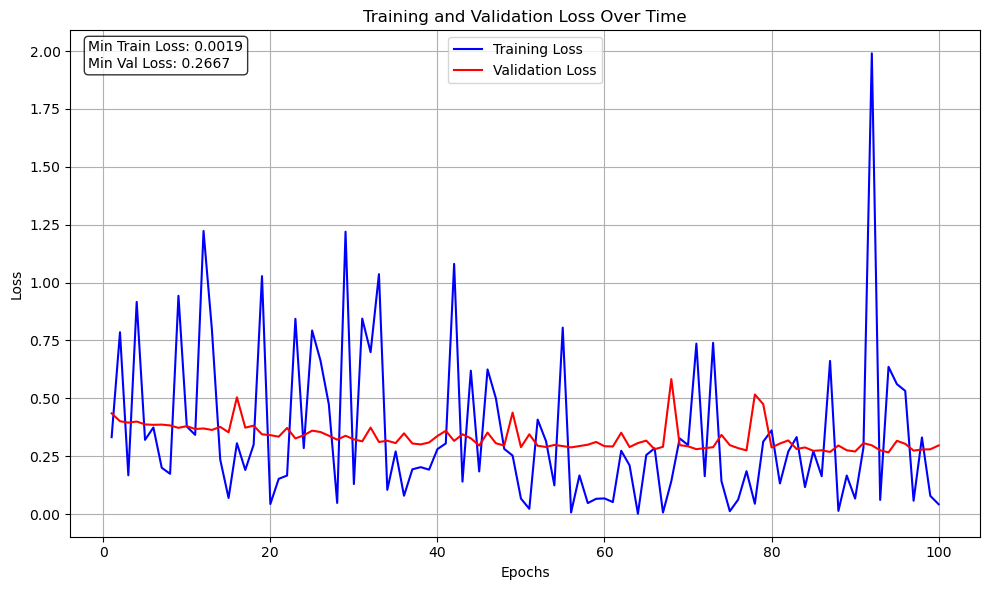

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Best model saved at: C:\Users\danie\Documents\GitHub\paparazzi\SmallConvNetwork\model_checkpoints\object_detection-epoch=93-val_loss=0.27.ckpt
Evaluating model on validation set...
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss            0.2666977643966675
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Validation results: [{'val_loss': 0.2666977643966675}]


In [147]:
import matplotlib.pyplot as plt
import numpy as np

class SimpleProgressCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []
        
    def on_train_epoch_start(self, trainer, pl_module):
        print(f"\nEpoch {trainer.current_epoch + 1}/{trainer.max_epochs}")
        
    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        train_loss = metrics.get('train_loss', 0)
        val_loss = metrics.get('val_loss', 0)
        
        # Store losses
        self.train_losses.append(float(train_loss))
        self.val_losses.append(float(val_loss))
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
    def plot_losses(self):
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.train_losses) + 1)
        
        plt.plot(epochs, self.train_losses, 'b-', label='Training Loss')
        plt.plot(epochs, self.val_losses, 'r-', label='Validation Loss')
        
        plt.title('Training and Validation Loss Over Time')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # Add min values as text
        min_train_loss = min(self.train_losses)
        min_val_loss = min(self.val_losses)
        plt.text(0.02, 0.98, f'Min Train Loss: {min_train_loss:.4f}\nMin Val Loss: {min_val_loss:.4f}', 
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return plt.gcf()

if train_model:
    # Initialize callback with progress tracking and loss history
    progress_callback = SimpleProgressCallback()
    
    # Setup PyTorch Lightning trainer
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        callbacks=[checkpoint_callback, progress_callback],
        check_val_every_n_epoch=1,
        enable_progress_bar=False,
        logger=False
    )
    
    # Explicitly setup the data module
    data_module.setup()
    
    # Train the model
    print("Starting model training...")
    print(f"Training on {len(data_module.train_dataset)} images")
    print(f"Validating on {len(data_module.val_dataset)} images")
    trainer.fit(model, data_module)
    
    # Plot the loss history
    loss_plot = progress_callback.plot_losses()
    plt.show()
    
    # Get the best checkpoint path
    best_model_path = checkpoint_callback.best_model_path
    if best_model_path:
        print(f"\nBest model saved at: {best_model_path}")
        # Load the best model
        model = (ObjectDetectionModel if isinstance(model, ObjectDetectionModel) else LightweightGridDetectionModel).load_from_checkpoint(
            best_model_path, 
            grid_lines=grid_lines, 
            danger_levels=danger_levels
        )
    else:
        print("\nNo checkpoints saved. Using the final model state.")
else:
    # Load model from a predefined checkpoint
    checkpoint_file = "checkpoint_filename.ckpt"  # Replace with checkpoint filename
    checkpoint_full_path = os.path.join(checkpoint_path, checkpoint_file)
    
    if os.path.exists(checkpoint_full_path):
        print(f"Loading model from checkpoint: {checkpoint_full_path}")
        model = ObjectDetectionModel.load_from_checkpoint(
            checkpoint_full_path, 
            grid_lines=grid_lines, 
            danger_levels=danger_levels
        )
    else:
        print(f"Checkpoint file not found: {checkpoint_full_path}")
        print("Proceeding with untrained model.")

print("Evaluating model on validation set...")
val_results = trainer.validate(model, datamodule=data_module)
print(f"Validation results: {val_results}")

In [ ]:
small_model = model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\danie\Documents\GitHub\paparazzi\SmallConvNetwork\model_checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | conv_features | Sequential | 173 K  | train
1 | fc_layers     | Sequential | 14.7 M | train
2 | loss_fn       | BCELoss    | 0      | train
-----------------------------------------------------
14.9 M    Trainable params
0         Non-trainable params
14.9 M    Total params
59.436    Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Using device: cuda
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
Starting model training...
Training on 1409 images
Validating on 261 images
[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels

Epoch 1/100


c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\danie\anaconda3\envs\cnn_onnx\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Train Loss: 0.7018, Val Loss: 0.2231

Epoch 2/100
Train Loss: 0.4044, Val Loss: 0.1626

Epoch 3/100
Train Loss: 0.0332, Val Loss: 0.1351

Epoch 4/100
Train Loss: 0.3760, Val Loss: 0.1530

Epoch 5/100
Train Loss: 0.7055, Val Loss: 0.1538

Epoch 6/100
Train Loss: 0.0017, Val Loss: 0.1412

Epoch 7/100
Train Loss: 0.1371, Val Loss: 0.1358

Epoch 8/100
Train Loss: 0.0004, Val Loss: 0.1300

Epoch 9/100
Train Loss: 0.0392, Val Loss: 0.1268

Epoch 10/100
Train Loss: 0.0713, Val Loss: 0.1628

Epoch 11/100
Train Loss: 0.0008, Val Loss: 0.1623

Epoch 12/100
Train Loss: 0.1397, Val Loss: 0.1594

Epoch 13/100
Train Loss: 0.0011, Val Loss: 0.1419

Epoch 14/100
Train Loss: 0.0000, Val Loss: 0.1678

Epoch 15/100
Train Loss: 0.0344, Val Loss: 0.1578

Epoch 16/100
Train Loss: 0.0019, Val Loss: 0.1641

Epoch 17/100
Train Loss: 0.0000, Val Loss: 0.2071

Epoch 18/100
Train Loss: 0.0006, Val Loss: 0.1678

Epoch 19/100
Train Loss: 0.0062, Val Loss: 0.2572

Epoch 20/100
Train Loss: 0.0011, Val Loss: 0.1575

E

`Trainer.fit` stopped: `max_epochs=100` reached.


Train Loss: 0.0000, Val Loss: 0.5716


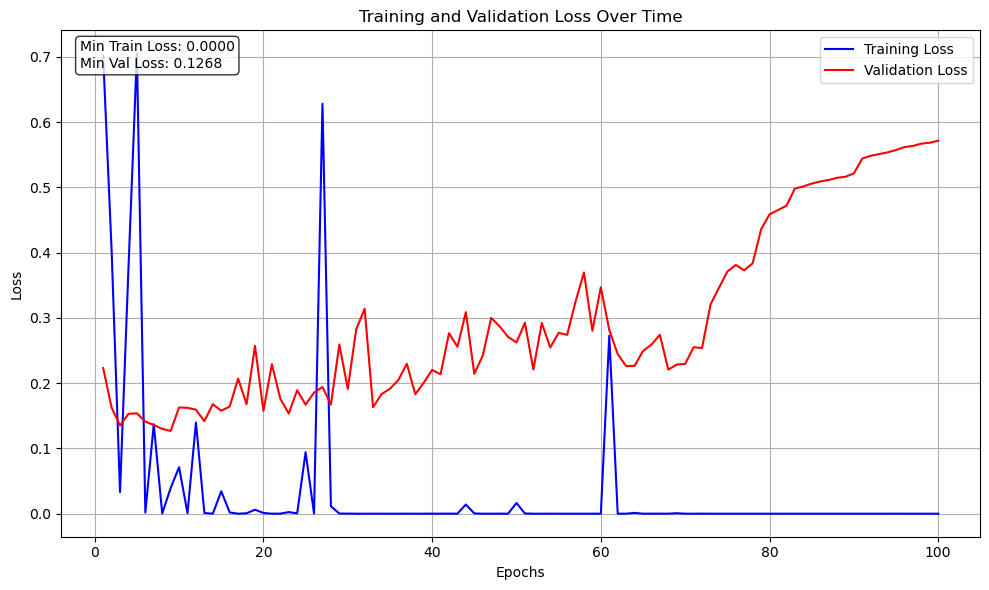


Best model saved at: C:\Users\danie\Documents\GitHub\paparazzi\SmallConvNetwork\model_checkpoints\object_detection-epoch=08-val_loss=0.13-v1.ckpt
Evaluating model on validation set...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[CustomImageDataset] Found 1409 images and 1409 labels
[CustomImageDataset] Found 261 images and 261 labels
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss            0.1268492490053177
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Validation results: [{'val_loss': 0.1268492490053177}]


In [148]:
import os
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define constants
width = 520
height = 240
image_dir_train = "./Dataset/dataset_syn/images/train"
image_dir_val = "./Dataset/dataset_syn/images/val"

# Set up grid lines
grid_lines = [[0, 0.2, 0.4, 0.6, 0.8, 1], [0, 1]]
grid_lines[0] = [line * width for line in grid_lines[0]]
grid_lines[1] = [line * height for line in grid_lines[1]]
danger_levels = 3

# Training parameters
max_epochs = 100  # Adjust as needed
batch_size = 8
checkpoint_path = "./model_checkpoints"
os.makedirs(checkpoint_path, exist_ok=True)

# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath=checkpoint_path,
    filename='object_detection-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    monitor='val_loss',
    mode='min'
)

# Training flag - set to True if you want to train the model, False to load a saved model
train_model = True

# Initialize our ONNX-compatible model
model = ObjectDetectionModel(grid_lines, danger_levels, input_shape=(3, height, width))
# model = LightweightGridDetectionModel(grid_lines, danger_levels, input_shape=(3, height, width))

# Initialize the data module
data_module = ObjectDetectionDataModule(
    image_dir_train, 
    image_dir_val, 
    width, 
    height, 
    grid_lines, 
    danger_levels, 
    batch_size=batch_size, 
    device=device
)

import matplotlib.pyplot as plt
import numpy as np

class SimpleProgressCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []
        
    def on_train_epoch_start(self, trainer, pl_module):
        print(f"\nEpoch {trainer.current_epoch + 1}/{trainer.max_epochs}")
        
    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        train_loss = metrics.get('train_loss', 0)
        val_loss = metrics.get('val_loss', 0)
        
        # Store losses
        self.train_losses.append(float(train_loss))
        self.val_losses.append(float(val_loss))
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
    def plot_losses(self):
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.train_losses) + 1)
        
        plt.plot(epochs, self.train_losses, 'b-', label='Training Loss')
        plt.plot(epochs, self.val_losses, 'r-', label='Validation Loss')
        
        plt.title('Training and Validation Loss Over Time')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # Add min values as text
        min_train_loss = min(self.train_losses)
        min_val_loss = min(self.val_losses)
        plt.text(0.02, 0.98, f'Min Train Loss: {min_train_loss:.4f}\nMin Val Loss: {min_val_loss:.4f}', 
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return plt.gcf()

if train_model:
    # Initialize callback with progress tracking and loss history
    progress_callback = SimpleProgressCallback()
    
    # Setup PyTorch Lightning trainer
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        callbacks=[checkpoint_callback, progress_callback],
        check_val_every_n_epoch=1,
        enable_progress_bar=False,
        logger=False
    )
    
    # Explicitly setup the data module
    data_module.setup()
    
    # Train the model
    print("Starting model training...")
    print(f"Training on {len(data_module.train_dataset)} images")
    print(f"Validating on {len(data_module.val_dataset)} images")
    trainer.fit(model, data_module)
    
    # Plot the loss history
    loss_plot = progress_callback.plot_losses()
    plt.show()
    
    # Get the best checkpoint path
    best_model_path = checkpoint_callback.best_model_path
    if best_model_path:
        print(f"\nBest model saved at: {best_model_path}")
        # Load the best model
        model = (ObjectDetectionModel if isinstance(model, ObjectDetectionModel) else LightweightGridDetectionModel).load_from_checkpoint(
            best_model_path, 
            grid_lines=grid_lines, 
            danger_levels=danger_levels
        )
    else:
        print("\nNo checkpoints saved. Using the final model state.")
else:
    # Load model from a predefined checkpoint
    checkpoint_file = "checkpoint_filename.ckpt"  # Replace with checkpoint filename
    checkpoint_full_path = os.path.join(checkpoint_path, checkpoint_file)
    
    if os.path.exists(checkpoint_full_path):
        print(f"Loading model from checkpoint: {checkpoint_full_path}")
        model = ObjectDetectionModel.load_from_checkpoint(
            checkpoint_full_path, 
            grid_lines=grid_lines, 
            danger_levels=danger_levels
        )
    else:
        print(f"Checkpoint file not found: {checkpoint_full_path}")
        print("Proceeding with untrained model.")

print("Evaluating model on validation set...")
val_results = trainer.validate(model, datamodule=data_module)
print(f"Validation results: {val_results}")

# Step 3: Evaluate the model on validation set

In [ ]:


print("Evaluating model on validation set...")
model.eval()
trainer = pl.Trainer(accelerator='gpu' if torch.cuda.is_available() else 'cpu')
val_results = trainer.validate(model, datamodule=data_module)
print(f"Validation results: {val_results}")


# Step 4: Visualize some predictions on validation data

In [ ]:

data_module.setup()
val_dataloader = data_module.val_dataloader()

# Get a batch of validation data
val_batch = next(iter(val_dataloader))
images, targets = val_batch

# Move the model to the same device as the input data
device = images.device
model = model.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(images)

# Display a few examples side by side
batch_size = images.shape[0]
num_examples = min(3, batch_size)

for i in range(num_examples):
    # Plot ground truth and prediction side by side
    plot_side_by_side(
        image=images[i],
        ground_truth=targets[i],
        prediction=predictions[i],
        grid_lines=grid_lines,
        example_num=i+1
    )
    plt.show()

# Step 5: Convert the PyTorch model to ONNX

In [ ]:
# Move model to CPU, then convert to ONNX
model = model.to('cpu')
dummy_input = torch.randn(1, 3, height, width, device='cpu')

export_to_onnx(model, input_shape=(1, 3, height, width), output_path="./light_object_detection.onnx")

In [ ]:

# Try loading the model to verify it works
import onnxruntime
ort_session = onnxruntime.InferenceSession("light_object_detection.onnx")

# Test with a sample input
test_input = images[0:1].cpu().numpy()
ort_inputs = {ort_session.get_inputs()[0].name: test_input}
ort_outputs = ort_session.run(None, ort_inputs)

print("Direct ONNX export successful!")

In [ ]:
def run_pytorch_onnx_comparison(model, onnx_path, data_module, num_examples=3):
    """
    Run comparison between PyTorch and ONNX models
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        num_examples: Number of examples to visualize
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Get a batch of validation data
    val_batch = next(iter(val_dataloader))
    images, targets = val_batch
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    images = images.to('cpu')
    targets = targets.to('cpu')
    
    # Get PyTorch predictions
    model.eval()
    with torch.no_grad():
        pytorch_predictions = model(images)
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # Get ONNX predictions
    onnx_inputs = {input_name: images.numpy()}
    onnx_outputs = ort_session.run(None, onnx_inputs)
    onnx_predictions = torch.from_numpy(onnx_outputs[0])
    
    # Display examples side by side
    batch_size = images.shape[0]
    num_examples = min(num_examples, batch_size)
    
    for i in range(num_examples):
        # Plot the comparison
        fig, axes = compare_pytorch_onnx_side_by_side(
            image=images[i],
            ground_truth=targets[i],
            pytorch_pred=pytorch_predictions[i],
            onnx_pred=onnx_predictions[i],
            grid_lines=grid_lines,
            example_num=i+1
        )
        plt.show()
        
        # Print numerical differences
        pt_gt_diff = torch.max(torch.abs(pytorch_predictions[i] - targets[i])).item()
        onnx_gt_diff = torch.max(torch.abs(onnx_predictions[i] - targets[i])).item()
        pt_onnx_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
        
        print(f"Example {i+1} - Maximum absolute differences:")
        print(f"  PyTorch vs Ground Truth: {pt_gt_diff:.6f}")
        print(f"  ONNX vs Ground Truth: {onnx_gt_diff:.6f}")
        print(f"  PyTorch vs ONNX: {pt_onnx_diff:.6f}")

# Run the comparison
run_pytorch_onnx_comparison(
    model=model, 
    onnx_path="./object_detection.onnx", 
    data_module=data_module,
    num_examples=3
)

In [ ]:
def compare_models_on_dataset(model, onnx_path, data_module, difference_threshold=0.01):
    """
    Compare PyTorch and ONNX models on the entire validation dataset and 
    find examples where they differ significantly
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        difference_threshold: Threshold to consider a difference significant
    
    Returns:
        list: List of tuples (image, ground_truth, pytorch_pred, onnx_pred, max_diff)
              for examples where the difference exceeds the threshold
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    model.eval()
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # List to store examples with significant differences
    significant_differences = []
    
    # Statistics
    total_examples = 0
    total_correct_match = 0
    difference_histogram = []
    
    # Process all batches
    print("Processing validation dataset...")
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_dataloader):
            # Move tensors to CPU
            images = images.to('cpu')
            targets = targets.to('cpu')
            
            # Get PyTorch predictions
            pytorch_predictions = model(images)
            
            # Get ONNX predictions
            onnx_inputs = {input_name: images.numpy()}
            onnx_outputs = ort_session.run(None, onnx_inputs)
            onnx_predictions = torch.from_numpy(onnx_outputs[0])
            
            # Compare predictions for each example in the batch
            for i in range(images.shape[0]):
                total_examples += 1
                
                # Calculate max absolute difference
                max_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
                difference_histogram.append(max_diff)
                
                # Check if predictions match exactly (after thresholding)
                threshold = 0.5
                pytorch_classes = (pytorch_predictions[i] > threshold).int()
                onnx_classes = (onnx_predictions[i] > threshold).int()
                
                exact_match = torch.all(pytorch_classes == onnx_classes).item()
                if exact_match:
                    total_correct_match += 1
                
                # If difference exceeds threshold, save this example
                if max_diff > difference_threshold or not exact_match:
                    significant_differences.append((
                        images[i].clone(),
                        targets[i].clone(),
                        pytorch_predictions[i].clone(),
                        onnx_predictions[i].clone(),
                        max_diff,
                        exact_match
                    ))
            
            # Print progress every few batches
            if (batch_idx + 1) % 5 == 0 or batch_idx == len(val_dataloader) - 1:
                print(f"Processed {batch_idx+1}/{len(val_dataloader)} batches, "
                      f"found {len(significant_differences)} examples with significant differences")
    
    # Print summary statistics
    print("\nValidation Dataset Summary:")
    print(f"Total examples processed: {total_examples}")
    print(f"Examples with exact class match: {total_correct_match} ({100 * total_correct_match / total_examples:.2f}%)")
    print(f"Examples with significant differences: {len(significant_differences)}")
    
    # Calculate and print difference statistics
    if difference_histogram:
        avg_diff = sum(difference_histogram) / len(difference_histogram)
        max_diff = max(difference_histogram)
        print(f"Average max difference: {avg_diff:.6f}")
        print(f"Maximum difference: {max_diff:.6f}")
    
    return significant_differences

# Run the comparison
significant_differences = compare_models_on_dataset(
    model=model, 
    onnx_path="./light_object_detection.onnx", 
    data_module=data_module,
    difference_threshold=0.0001  # Adjust this threshold as needed
)

print(f"\nFound {len(significant_differences)} examples with significant differences")

In [2]:
import onnx
import numpy as np
import sys
import os

def analyze_onnx_model(model_path):
    """
    Analyze an ONNX model and print detailed information
    
    Args:
        model_path: Path to the ONNX model file
    """
    print(f"Analyzing ONNX model: {model_path}")
    print("-" * 80)
    
    # Load the ONNX model
    model = onnx.load(model_path)
    
    # Check model validity
    try:
        onnx.checker.check_model(model)
        print("✓ Model is valid")
    except Exception as e:
        print(f"✗ Model is invalid: {e}")
    
    # Basic model info
    print("\n== Model Info ==")
    print(f"IR Version: {model.ir_version}")
    print(f"Producer: {model.producer_name} {model.producer_version}")
    print(f"Domain: {model.domain}")
    print(f"Model Version: {model.model_version}")
    print(f"Doc: {model.doc_string}")
    
    # Count nodes by type
    node_types = {}
    for node in model.graph.node:
        if node.op_type in node_types:
            node_types[node.op_type] += 1
        else:
            node_types[node.op_type] = 1
    
    print("\n== Node Types ==")
    for op_type, count in sorted(node_types.items()):
        print(f"{op_type}: {count}")
    print(f"Total nodes: {len(model.graph.node)}")
    
    # Analyze inputs
    print("\n== Inputs ==")
    for i, input_data in enumerate(model.graph.input):
        name = input_data.name
        shape = []
        for dim in input_data.type.tensor_type.shape.dim:
            if dim.dim_param:
                shape.append(dim.dim_param)
            else:
                shape.append(dim.dim_value)
        print(f"Input #{i}: {name}, Shape: {shape}")
    
    # Analyze outputs
    print("\n== Outputs ==")
    for i, output in enumerate(model.graph.output):
        name = output.name
        shape = []
        for dim in output.type.tensor_type.shape.dim:
            if dim.dim_param:
                shape.append(dim.dim_param)
            else:
                shape.append(dim.dim_value)
        print(f"Output #{i}: {name}, Shape: {shape}")
    
    # Analyze initializers (weights and biases)
    print("\n== Initializers (Parameters) ==")
    total_params = 0
    total_size_bytes = 0
    
    for i, initializer in enumerate(model.graph.initializer):
        shape = [dim for dim in initializer.dims]
        num_params = np.prod(shape)
        total_params += num_params
        
        # Calculate memory size
        elem_type = initializer.data_type
        bytes_per_element = 4  # Default for float32
        if elem_type == 1:  # FLOAT
            bytes_per_element = 4
        elif elem_type == 2:  # UINT8
            bytes_per_element = 1
        elif elem_type == 3:  # INT8
            bytes_per_element = 1
        elif elem_type == 5:  # INT16
            bytes_per_element = 2
        elif elem_type == 6:  # INT32
            bytes_per_element = 4
        elif elem_type == 7:  # INT64
            bytes_per_element = 8
        elif elem_type == 10:  # FLOAT16
            bytes_per_element = 2
        elif elem_type == 11:  # DOUBLE
            bytes_per_element = 8
            
        param_size_bytes = num_params * bytes_per_element
        total_size_bytes += param_size_bytes
        
        print(f"Initializer #{i}: {initializer.name}")
        print(f"  Shape: {shape}, Elements: {num_params}, Size: {format_bytes(param_size_bytes)}")
    
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Total parameter size: {format_bytes(total_size_bytes)}")
    
    # Estimate C file size (parameters + overhead)
    estimated_c_file_size = total_size_bytes * 7  # Rough estimate based on float representation in C
    print(f"Estimated C file size: {format_bytes(estimated_c_file_size)} (rough estimate)")
    
    print("\n== Memory Analysis ==")
    print(f"Parameter memory: {format_bytes(total_size_bytes)}")
    
    # Estimate activation memory based on intermediate tensors
    # This is a rough estimation
    activation_memory = 0
    for node in model.graph.node:
        for output in node.output:
            # Find corresponding value info if available
            for value_info in model.graph.value_info:
                if value_info.name == output:
                    shape = [dim.dim_value for dim in value_info.type.tensor_type.shape.dim]
                    if all(shape):  # Only count if we have complete shape info
                        activation_memory += np.prod(shape) * 4  # Assuming float32
    
    print(f"Activation memory (estimated): {format_bytes(activation_memory)}")
    print(f"Total memory footprint (estimated): {format_bytes(total_size_bytes + activation_memory)}")

def format_bytes(size):
    """Format bytes to human-readable string"""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size < 1024.0 or unit == 'GB':
            return f"{size:.2f} {unit}"
        size /= 1024.0

analyze_onnx_model('model_rgb.onnx')

Analyzing ONNX model: model_rgb.onnx
--------------------------------------------------------------------------------
✓ Model is valid

== Model Info ==
IR Version: 8
Producer: pytorch 2.6.0
Domain: 
Model Version: 0
Doc: 

== Node Types ==
Constant: 3
Conv: 4
Div: 1
Gemm: 2
MaxPool: 3
Relu: 5
Reshape: 2
Total nodes: 20

== Inputs ==
Input #0: onnx::Div_0, Shape: [1, 3, 520, 240]

== Outputs ==
Output #0: 44, Shape: [1, 5]

== Initializers (Parameters) ==
Initializer #0: conv.1.weight
  Shape: [16, 3, 3, 3], Elements: 432, Size: 1.69 KB
Initializer #1: conv.1.bias
  Shape: [16], Elements: 16, Size: 64.00 B
Initializer #2: conv.3.weight
  Shape: [64, 16, 3, 3], Elements: 9216, Size: 36.00 KB
Initializer #3: conv.3.bias
  Shape: [64], Elements: 64, Size: 256.00 B
Initializer #4: conv.6.weight
  Shape: [128, 64, 3, 3], Elements: 73728, Size: 288.00 KB
Initializer #5: conv.6.bias
  Shape: [128], Elements: 128, Size: 512.00 B
Initializer #6: conv.8.weight
  Shape: [32, 128, 1, 1], Elements:

# Convert ONNX model to C using ONNX2C (Ubuntu only)

Setup docker with the docker file in the folder (make sure working directory contains the docker file):

```  sudo docker build -t onnx2c-fixed . ```

```sudo docker run --rm -v $(pwd):/data onnx2c-fixed light_object_detection.onnx > light_object_detection.c```


# Validate the C model with our onnx model

Loading image: ./dataset/images/train/19382713.jpg
Image preprocessed to shape: (1, 3, 520, 240)
Saving input tensor to: /tmp/temp_input.bin
Running ONNX model: model_rgb.onnx
ONNX model expected input shape: [1, 3, 520, 240]
Actual input tensor shape: (1, 3, 520, 240)
Raw ONNX output shape: (1, 5)
Running C model: build/model_runner_grid
C model output: Model output summary:
Danger level 0:
  Column 0: 0.0424
  Column 1: 0.1036
  Column 2: 0.0701
  Column 3: 0.1101
  Column 4: 0.0172
Danger level 1:
  Column 0: 0.0000
  Column 1: 0.0000
  Column 2: 0.0000
  Column 3: 0.0000
  Column 4: 0.0000
Danger level 2:
  Column 0: 0.0000
  Column 1: 0.0000
  Column 2: 0.0000
  Column 3: 0.0000
  Column 4: 0.0000

ONNX output shape: (1, 3, 5, 1)
C model output shape: (1, 3, 5, 1)
Both models ran successfully! Comparing results...

Differences between ONNX and C predictions:
  Maximum absolute difference: 0.000000
  Average absolute difference: 0.000000


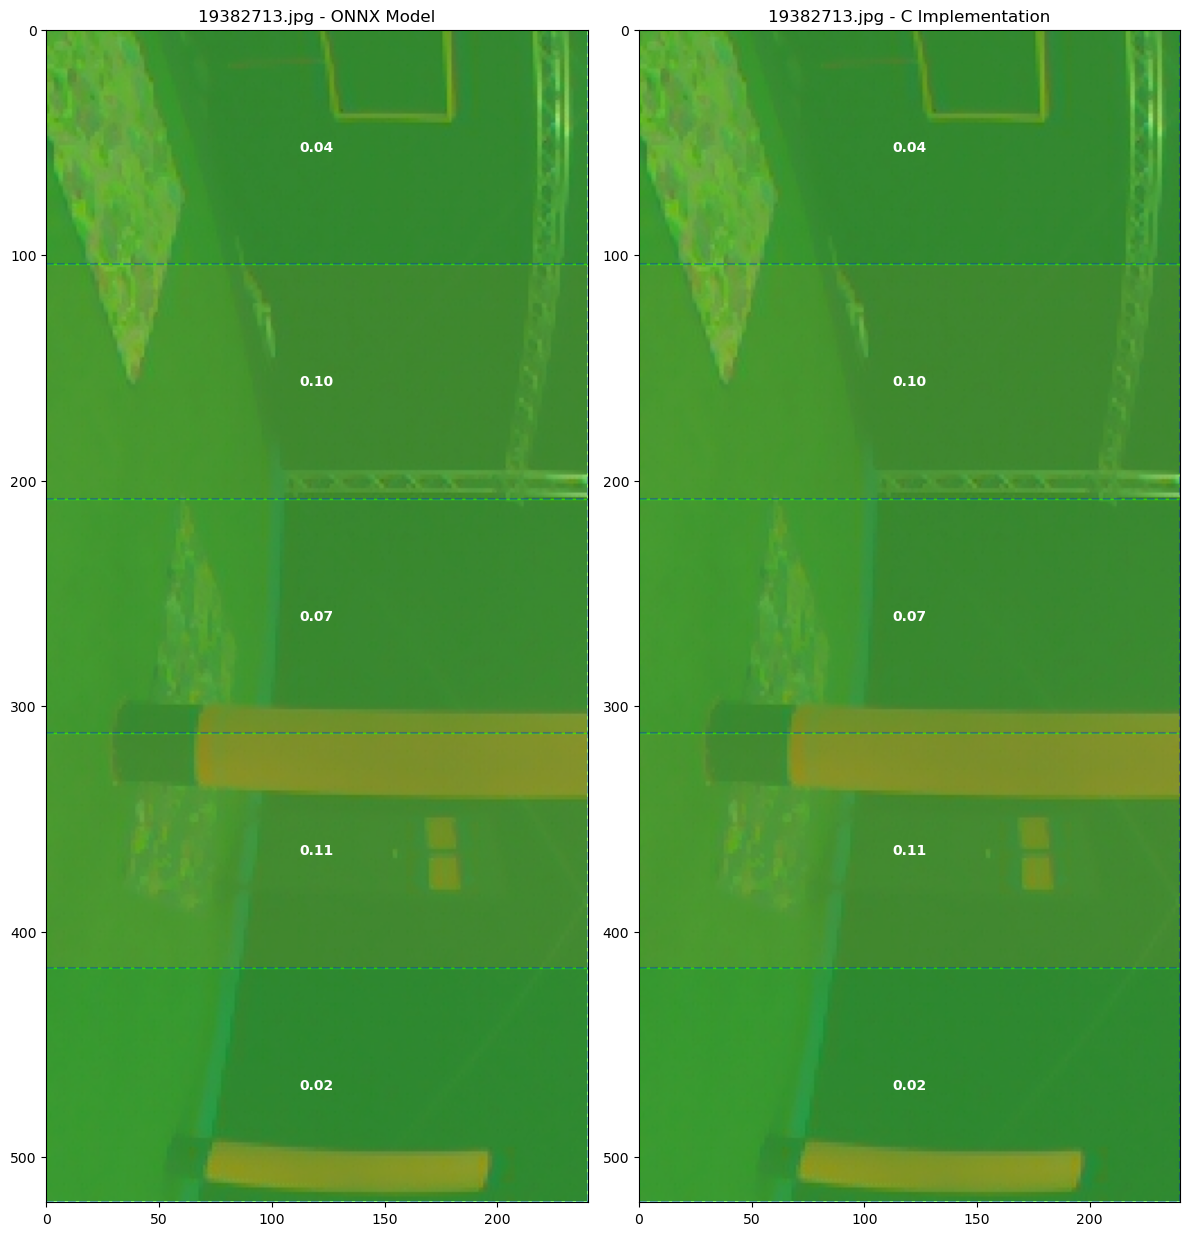

In [14]:
# ONNX vs C Grid Model Comparison Notebook

import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime
import tempfile
from PIL import Image
import cv2

# Configuration
onnx_model_path = "rgb_model.onnx"  # Update with your grid-based ONNX model path
c_executable = "build/Debug/model_runner_grid"   # Update with your executable path
# You'll need to provide a test image path when running

def load_and_preprocess_image(image_path, target_size=(520, 240)):
    """Load and preprocess an image for the model"""
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Rotate image 90 degrees clockwise
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    
    # Resize image to target size (height, width)
    img = cv2.resize(img, (target_size[1], target_size[0]))  # cv2.resize expects (width, height)
    
    # Convert to float32 and normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    # Convert to NCHW format (1, 3, 520, 240)
    img = img.transpose(2, 0, 1)
    
    # Add batch dimension
    img = np.expand_dims(img, axis=0)
    
    # For display purposes, we'll return the rotated image in HWC format
    display_img = img[0].transpose(1, 2, 0)
    
    return img, display_img

def save_input_to_bin(input_tensor, output_file):
    """Save input tensor to binary file for C model"""
    expected_shape = (1, 3, 520, 240)
    if input_tensor.shape != expected_shape:
        print(f"Warning: Reshaping input tensor from {input_tensor.shape} to {expected_shape}")
        input_tensor = input_tensor.reshape(expected_shape)
    
    flat_input = input_tensor.flatten()
    flat_input.tofile(output_file)
    return output_file

def run_c_model(exe_path, input_file, output_file):
    """Run the C model executable"""
    try:
        result = subprocess.run(
            [exe_path, input_file, output_file],
            check=True,
            capture_output=True,
            text=True
        )
        if result.stdout:
            print("C model output:", result.stdout)
        if result.stderr:
            print("C model errors:", result.stderr)
        
        # Load the output binary file
        if os.path.exists(output_file):
            output = np.fromfile(output_file, dtype=np.float32)
            # Reshape to match the grid-based output format [1, 3, 5, 1]
            output = output.reshape(1, 3, 5, 1)
            return output
        else:
            print(f"Error: C model output file '{output_file}' was not created")
            return None
    except subprocess.CalledProcessError as e:
        print(f"Error running C model: {e}")
        if e.stdout:
            print("stdout:", e.stdout)
        if e.stderr:
            print("stderr:", e.stderr)
        return None

def run_onnx_model(onnx_path, input_tensor):
    """Run ONNX model using ONNX Runtime"""
    try:
        ort_session = onnxruntime.InferenceSession(onnx_path)
        input_name = ort_session.get_inputs()[0].name
        
        # Print input shape information for debugging
        print("ONNX model expected input shape:", ort_session.get_inputs()[0].shape)
        print("Actual input tensor shape:", input_tensor.shape)
        
        # Run inference
        onnx_inputs = {input_name: input_tensor}
        onnx_outputs = ort_session.run(None, onnx_inputs)
        
        # Get the output and reshape it to match C model
        onnx_result = np.array(onnx_outputs[0])
        print("Raw ONNX output shape:", onnx_result.shape)
        
        # Reshape to match C model output
        if onnx_result.shape == (1, 5):
            # If we're getting a flat output, reshape it to match the C model's shape
            onnx_result = np.zeros((1, 3, 5, 1))  # Initialize with zeros
            onnx_result[0, 0, :, 0] = onnx_outputs[0][0]  # Safe level
            # Warning and Danger levels remain 0
        
        return onnx_result
    except Exception as e:
        print(f"Error running ONNX model: {e}")
        return None

def compare_grid_predictions(image, onnx_pred, c_pred, title=None):
    """
    Plot ONNX and C model grid predictions side by side
    
    Args:
        image: Rotated display image (H=520, W=240, C)
        onnx_pred: ONNX model prediction of shape (1, 5) - danger scores 0 to 1
        c_pred: C model prediction of shape (1, 5) - danger scores 0 to 1
        title: Optional title
    """
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 16))
    
    # Plot base images
    ax1.imshow(image)
    ax1.set_title("ONNX Model Prediction" if title is None else f"{title} - ONNX Model")
    
    ax2.imshow(image)
    ax2.set_title("C Implementation" if title is None else f"{title} - C Implementation")
    
    # Generate grid lines
    img_h, img_w = image.shape[:2]  # height=520, width=240
    grid_y = 5  # Number of rows
    grid_x = 1  # Number of columns
    
    # Calculate grid line positions
    y_lines = [int(i * img_h / grid_y) for i in range(grid_y + 1)]
    x_lines = [int(i * img_w / grid_x) for i in range(grid_x + 1)]
    
    # Draw grid lines on both plots
    for x in x_lines:
        ax1.axvline(x, color='blue', linestyle='--', alpha=0.3)
        ax2.axvline(x, color='blue', linestyle='--', alpha=0.3)
    for y in y_lines:
        ax1.axhline(y, color='blue', linestyle='--', alpha=0.3)
        ax2.axhline(y, color='blue', linestyle='--', alpha=0.3)
    
    def get_color(value):
        """Convert value between 0 and 1 to RGB color"""
        if value <= 0.5:
            # Interpolate between green and yellow
            r = 2 * value
            g = 1.0
            b = 0.0
        else:
            # Interpolate between yellow and red
            r = 1.0
            g = 2 * (1 - value)
            b = 0.0
        return (r, g, b)
    
    # Draw predictions for ONNX model (left)
    onnx_values = onnx_pred.reshape(-1)  # Flatten to 5 values
    for i in range(grid_y):  # Iterate over rows
        y1, y2 = y_lines[i], y_lines[i + 1]
        for j in range(grid_x):  # Iterate over columns
            x1, x2 = x_lines[j], x_lines[j + 1]
            
            value = float(onnx_values[i])
            color = get_color(value)
            
            # Fill cell with interpolated color
            ax1.fill_between([x1, x2], [y1, y1], [y2, y2], 
                            color=color, alpha=0.4)
            
            # Add text label showing value
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            ax1.text(center_x, center_y, f"{value:.2f}", 
                    ha='center', va='center', 
                    color='white', fontweight='bold')
    
    # Draw predictions for C model (right)
    c_values = c_pred.reshape(-1)  # Flatten to 5 values
    for i in range(grid_y):  # Iterate over rows
        y1, y2 = y_lines[i], y_lines[i + 1]
        for j in range(grid_x):  # Iterate over columns
            x1, x2 = x_lines[j], x_lines[j + 1]
            
            value = float(c_values[i])
            color = get_color(value)
            
            # Fill cell with interpolated color
            ax2.fill_between([x1, x2], [y1, y1], [y2, y2], 
                            color=color, alpha=0.4)
            
            # Add text label showing value
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            ax2.text(center_x, center_y, f"{value:.2f}", 
                    ha='center', va='center',
                    color='white', fontweight='bold')
    
    # # Add colorbar legend
    # norm = plt.Normalize(0, 1)
    # cmap = plt.cm.RdYlGn_r  # Red-Yellow-Green colormap, reversed
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=[ax1, ax2], orientation='vertical', label='Danger Score')
    # cbar.set_ticks([0, 0.5, 1])
    # cbar.set_ticklabels(['Safe (0)', 'Medium (0.5)', 'Danger (1)'])
    
    # Set axes limits
    ax1.set_xlim(0, img_w)
    ax1.set_ylim(img_h, 0)  # Inverted y-axis for image coordinates
    ax2.set_xlim(0, img_w)
    ax2.set_ylim(img_h, 0)
    
    plt.tight_layout()
    
    # Print numerical differences between ONNX and C predictions
    if onnx_pred is not None and c_pred is not None:
        diff = np.abs(onnx_pred - c_pred)
        max_diff = np.max(diff)
        avg_diff = np.mean(diff)
        print("\nDifferences between ONNX and C predictions:")
        print(f"  Maximum absolute difference: {max_diff:.6f}")
        print(f"  Average absolute difference: {avg_diff:.6f}")
    
    return fig, (ax1, ax2)

def compare_and_visualize(image_path, onnx_model_path=onnx_model_path, c_executable=c_executable):
    """Run comparison on the given image and visualize results"""
    # Check if files exist
    for path, name in [(image_path, 'Image'), (onnx_model_path, 'ONNX model'), (c_executable, 'C executable')]:
        if not os.path.exists(path):
            print(f"Error: {name} file '{path}' does not exist")
            return
    
    # Load and preprocess image
    print(f"Loading image: {image_path}")
    try:
        # Preprocess for model
        input_tensor, display_img = load_and_preprocess_image(image_path)
        print(f"Image preprocessed to shape: {input_tensor.shape}")
    except Exception as e:
        print(f"Error loading image: {e}")
        return
    
    # Create temporary files for C model
    temp_input = os.path.join(tempfile.gettempdir(), "temp_input.bin")
    temp_output = os.path.join(tempfile.gettempdir(), "temp_output.bin")
    
    # Save input tensor to binary file
    print(f"Saving input tensor to: {temp_input}")
    save_input_to_bin(input_tensor, temp_input)
    
    # Run ONNX model
    print(f"Running ONNX model: {onnx_model_path}")
    onnx_result = run_onnx_model(onnx_model_path, input_tensor)
    
    # Run C model
    print(f"Running C model: {c_executable}")
    c_result = run_c_model(c_executable, temp_input, temp_output)

    # Add shape debugging
    if onnx_result is not None:
        print("ONNX output shape:", onnx_result.shape)
    if c_result is not None:
        print("C model output shape:", c_result.shape)
    
    # Compare results
    if onnx_result is not None and c_result is not None:
        print("Both models ran successfully! Comparing results...")
        fig, _ = compare_grid_predictions(
            image=display_img,
            onnx_pred=onnx_result,
            c_pred=c_result,
            title=os.path.basename(image_path)
        )
        plt.show()
    else:
        if onnx_result is None:
            print("Failed to get results from ONNX model")
        if c_result is None:
            print("Failed to get results from C model")
    
    # Clean up temporary files
    for temp_file in [temp_input, temp_output]:
        if os.path.exists(temp_file):
            os.remove(temp_file)

# Example usage
compare_and_visualize(
    "./dataset/images/train/19382713.jpg",
    onnx_model_path="model_rgb.onnx",
    c_executable="build/model_runner_grid"  # Linux path
)